# Project: RCCI Data Analysis (University of Vaasa)
## Title: Effect of Automatic Relevancy Determination (ARD) on Engine Data
> Data Preprocessing, Data Encoding, Data Analysis, Results and Insights

In [96]:
import os, sys
print("cwd:", os.getcwd())
print("sys.path[:5]:", sys.path[:5])

cwd: D:\shahnawaz\uva\main
sys.path[:5]: ['C:\\Users\\shahmed-adm\\AppData\\Local\\Programs\\Python\\Python313\\python313.zip', 'C:\\Users\\shahmed-adm\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\shahmed-adm\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\shahmed-adm\\AppData\\Local\\Programs\\Python\\Python313', '']


In [97]:
%cd D:\shahnawaz\uva\main

D:\shahnawaz\uva\main


In [143]:
%load_ext autoreload
%autoreload 2

from src.data_loader import DataLoader
from src.data_analyzer import DataAnalyzer
from src.constant_manager import ConstantManager
from src.data_cleaner import DataCleaner
from src.feature_renamer import FeatureRenamer
from src.scaler import Scaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [99]:
# file names declared globally for easy access
RAW_DATA_FILE = 'rcci_data.xlsx'
PD_DATA_FILE = 'rcci_cleaned_data.parquet'

## XLSX Raw data reading and preprocessing

In [113]:
input_features = ['Boost pressure', 'Mass1', 'Mass2', 'Mass3', 'SOI1', 'SOI2', 'SOI3', 'H2/NG ratio', 'IVO', 'IVC', 'EVO', 'EVC']
output_features = ['IEMP', 'ITE', 'CA50', 'Lambda', 'PRR4_max', 'Pmax_CYL4', 'Nox', 'CH4', 'CO', 'NMHC', 'CO2']

loader = DataLoader(file_path='rcci_data.xlsx')

data = loader.load_data(
    rename_columns=False,
    ignore_unnamed=True,
    skiprows=[0, 2],
    index_col=0,
    header=0
)

data.head()

,Engine_speed,PARAM 1,PARAM 2,Boost pressure,Mass1,Mass2,Mass3,SOI1,SOI2,SOI3,...,ITE,CA50,Lambda,PRR4_max,Pmax_CYL4,Nox,CH4,CO,NMHC,CO2
Parameter,,,,,,,,,,,,,,,,,,,,,
Case1,1001.619019,IVO,NaN,2.432707,16.148115,1.356,0,290,50,0,...,0.427051,9.741974,2.114984,2.902092,117.721092,161.790000,5273.386667,1118.906667,53.406667,33866.666667
Case2,1002.648621,IVO,NaN,2.416656,16.303976,1.384,0,290,50,0,...,0.455489,7.666809,2.055653,4.132198,129.963547,184.626667,3013.136667,707.303333,32.713333,37733.333333
Case3,1001.856995,IVO,NaN,2.417493,16.142748,1.354,0,290,50,0,...,0.464826,7.060852,2.059422,4.625538,132.970169,208.396667,2206.723333,559.876667,29.113333,39100.000000
Case4,1002.229736,IVO,NaN,2.402269,16.059692,1.378,0,290,50,0,...,0.474853,4.508942,2.053768,6.291973,144.989441,256.036667,1309.956667,339.750000,16.836667,40366.666667
Case5,1002.128906,IVO,NaN,2.398758,15.922473,1.378,0,290,50,0,...,0.473512,-0.168091,2.017220,9.679886,163.729141,635.970000,614.646667,167.550000,13.360000,42966.666667


In [114]:
# data cleaning process
cleaner = DataCleaner(data)
non_empty_df = cleaner.exclude_null_columns(consider_zeros_as_null=True)

non_empty_df.head()

,Engine_speed,PARAM 1,PARAM 2,Boost pressure,Mass1,Mass2,SOI1,SOI2,IVO,IVC,...,ITE,CA50,Lambda,PRR4_max,Pmax_CYL4,Nox,CH4,CO,NMHC,CO2
Parameter,,,,,,,,,,,,,,,,,,,,,
Case1,1001.619019,IVO,NaN,2.432707,16.148115,1.356,290,50,345,516,...,0.427051,9.741974,2.114984,2.902092,117.721092,161.790000,5273.386667,1118.906667,53.406667,33866.666667
Case2,1002.648621,IVO,NaN,2.416656,16.303976,1.384,290,50,355,516,...,0.455489,7.666809,2.055653,4.132198,129.963547,184.626667,3013.136667,707.303333,32.713333,37733.333333
Case3,1001.856995,IVO,NaN,2.417493,16.142748,1.354,290,50,365,516,...,0.464826,7.060852,2.059422,4.625538,132.970169,208.396667,2206.723333,559.876667,29.113333,39100.000000
Case4,1002.229736,IVO,NaN,2.402269,16.059692,1.378,290,50,375,516,...,0.474853,4.508942,2.053768,6.291973,144.989441,256.036667,1309.956667,339.750000,16.836667,40366.666667
Case5,1002.128906,IVO,NaN,2.398758,15.922473,1.378,290,50,385,516,...,0.473512,-0.168091,2.017220,9.679886,163.729141,635.970000,614.646667,167.550000,13.360000,42966.666667


In [115]:
# checking null values in the cleaned dataframe
nulls = cleaner.null_check()
print("Null values in each column:\n", nulls)

Null values in each column:
 PARAM 2    42
dtype: int64


In [116]:
encoded_df = cleaner.encode_joint_categorical_columns(col1='PARAM 1', col2='PARAM 2', new_col_name='Comb')
encoded_df.head(20)

,Engine_speed,Boost pressure,Mass1,Mass2,SOI1,SOI2,IVO,IVC,EVO,EVC,...,NMHC,CO2,Comb_Boost_None,Comb_EVC_None,Comb_EVO_None,Comb_IVC_None,Comb_IVO_EVC,Comb_IVO_None,Comb_Mass2_None,Comb_SOI2_None
Parameter,,,,,,,,,,,,,,,,,,,,,
Case1,1001.619019,2.432707,16.148115,1.356,290,50,345,516,158,351,...,53.406667,33866.666667,False,False,False,False,False,True,False,False
Case2,1002.648621,2.416656,16.303976,1.384,290,50,355,516,158,351,...,32.713333,37733.333333,False,False,False,False,False,True,False,False
Case3,1001.856995,2.417493,16.142748,1.354,290,50,365,516,158,351,...,29.113333,39100.000000,False,False,False,False,False,True,False,False
Case4,1002.229736,2.402269,16.059692,1.378,290,50,375,516,158,351,...,16.836667,40366.666667,False,False,False,False,False,True,False,False
Case5,1002.128906,2.398758,15.922473,1.378,290,50,385,516,158,351,...,13.360000,42966.666667,False,False,False,False,False,True,False,False
Case6,1002.274475,2.442164,15.985152,1.516,290,50,355,511,158,351,...,45.160000,37475.000000,False,False,False,True,False,False,False,False
Case7,1002.209167,2.415214,16.248457,1.362,290,50,355,516,158,351,...,33.000000,37666.666667,False,False,False,True,False,False,False,False
Case8,1001.886902,2.420942,16.216175,1.384,290,50,355,526,158,351,...,22.367500,37225.000000,False,False,False,True,False,False,False,False
Case9,1001.971008,2.424881,16.224947,1.367,290,50,355,536,158,351,...,19.610000,36566.666667,False,False,False,True,False,False,False,False


In [117]:
# check null values in the encoded dataframe
encoded_nulls = cleaner.null_check()
print("Null values in each column of the encoded dataframe:\n", encoded_nulls)

Null values in each column of the encoded dataframe:
 Series([], dtype: int64)


In [118]:
# rename columns to match input and output features
input_features = ConstantManager().RAW_INPUT_COLUMNS
output_features = ConstantManager().RAW_OUTPUT_COLUMNS
categorical_features = ConstantManager().RAW_CATEGORICAL_COLUMNS

feature_renamer = FeatureRenamer(encoded_df, input_features, output_features, categorical_features)

renamed_df = feature_renamer.rename_columns()
renamed_df.head()

,Engine_speed,if_1,if_2,if_3,if_4,if_5,if_6,if_7,if_8,if_9,...,of_10,of_11,cf_1,cf_2,cf_3,cf_4,cf_5,cf_6,cf_7,cf_8
Parameter,,,,,,,,,,,,,,,,,,,,,
Case1,1001.619019,2.432707,16.148115,1.356,290,50,345,516,158,351,...,53.406667,33866.666667,False,False,False,False,False,True,False,False
Case2,1002.648621,2.416656,16.303976,1.384,290,50,355,516,158,351,...,32.713333,37733.333333,False,False,False,False,False,True,False,False
Case3,1001.856995,2.417493,16.142748,1.354,290,50,365,516,158,351,...,29.113333,39100.000000,False,False,False,False,False,True,False,False
Case4,1002.229736,2.402269,16.059692,1.378,290,50,375,516,158,351,...,16.836667,40366.666667,False,False,False,False,False,True,False,False
Case5,1002.128906,2.398758,15.922473,1.378,290,50,385,516,158,351,...,13.360000,42966.666667,False,False,False,False,False,True,False,False


In [119]:
duplicates = cleaner.check_duplicates()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [120]:
# save the cleaned and renamed dataframe to a new file
print(loader.save_df_to_parquet(renamed_df, PD_DATA_FILE))

rcci_cleaned_data.parquet


## Read and analyze the cleaned dataframe

In [192]:
pd_loader = DataLoader(file_path=PD_DATA_FILE)
pd_df = pd_loader.load_data()

pd_df.head()

,Engine_speed,if_1,if_2,if_3,if_4,if_5,if_6,if_7,if_8,if_9,...,of_10,of_11,cf_1,cf_2,cf_3,cf_4,cf_5,cf_6,cf_7,cf_8
Parameter,,,,,,,,,,,,,,,,,,,,,
Case1,1001.619019,2.432707,16.148115,1.356,290,50,345,516,158,351,...,53.406667,33866.666667,False,False,False,False,False,True,False,False
Case2,1002.648621,2.416656,16.303976,1.384,290,50,355,516,158,351,...,32.713333,37733.333333,False,False,False,False,False,True,False,False
Case3,1001.856995,2.417493,16.142748,1.354,290,50,365,516,158,351,...,29.113333,39100.000000,False,False,False,False,False,True,False,False
Case4,1002.229736,2.402269,16.059692,1.378,290,50,375,516,158,351,...,16.836667,40366.666667,False,False,False,False,False,True,False,False
Case5,1002.128906,2.398758,15.922473,1.378,290,50,385,516,158,351,...,13.360000,42966.666667,False,False,False,False,False,True,False,False


In [193]:
if_names, of_names, cat_names = feature_renamer.get_renamed_column_names()

print("Renamed Input Features:", if_names)

Renamed Input Features: ['if_1', 'if_2', 'if_3', 'if_4', 'if_5', 'if_6', 'if_7', 'if_8', 'if_9']


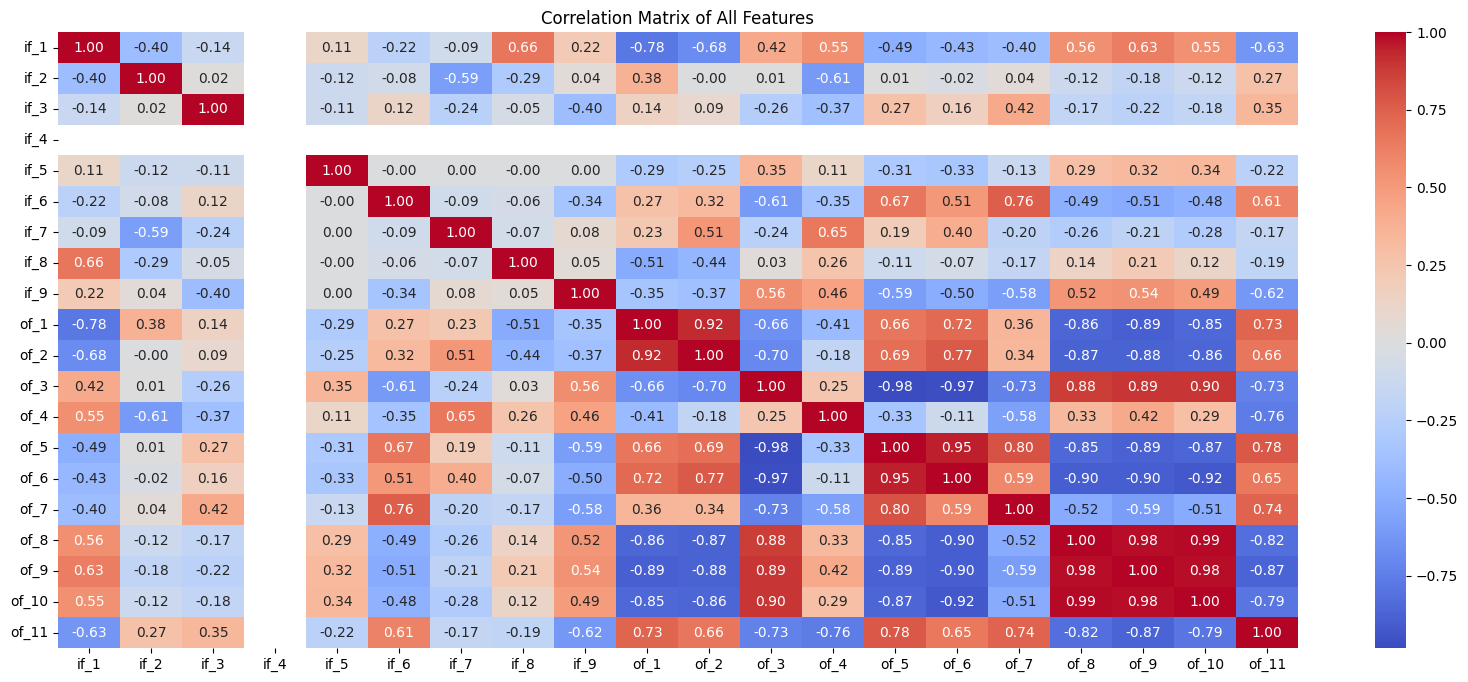

In [210]:
import seaborn as sns

# correlation analysis of input and output features
features_corr = pd_df[if_names + of_names].corr()
plt.figure(figsize=(20, 8))
plt.title("Correlation Matrix of All Features")
sns.heatmap(features_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

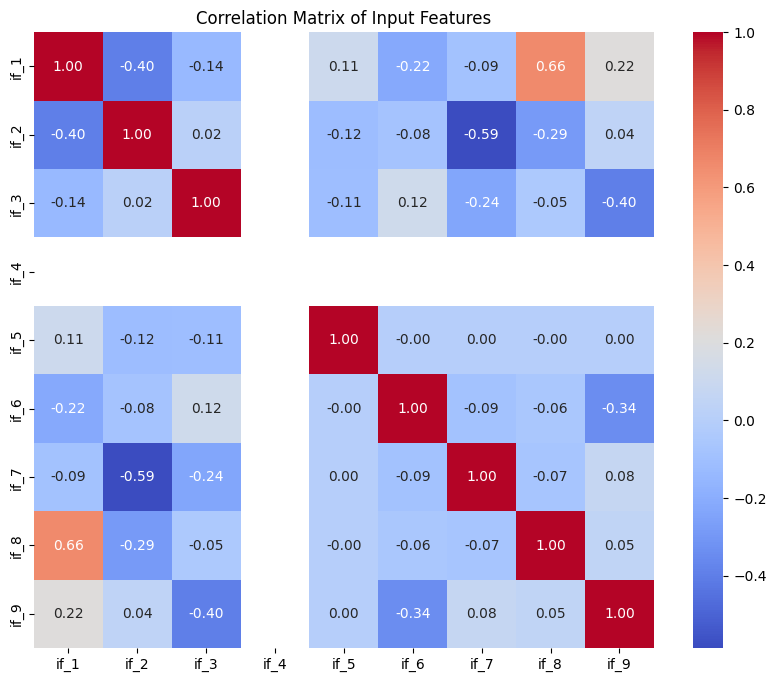

In [194]:
import seaborn as sns

# correlation analysis of input features excluding if_4
input_corr = pd_df[if_names].corr()
plt.figure(figsize=(10, 8))
plt.title("Correlation Matrix of Input Features")
sns.heatmap(input_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [195]:
scaler_x = Scaler()
scaler_y = Scaler()

scaled_df = pd_df.copy()
scaled_df[if_names] = scaler_x.fit_transform(scaled_df, if_names)
scaled_df[of_names] = scaler_y.fit_transform(scaled_df, of_names)

In [168]:
scaled_df.head()

,Engine_speed,if_1,if_2,if_3,if_4,if_5,if_6,if_7,if_8,if_9,...,of_10,of_11,cf_1,cf_2,cf_3,cf_4,cf_5,cf_6,cf_7,cf_8
Parameter,,,,,,,,,,,,,,,,,,,,,
Case1,1001.619019,0.136000,0.297790,-1.021125,0.0,0.0,-1.897446,-0.329596,-0.218565,0.228558,...,1.979368,-1.620113,False,False,False,False,False,True,False,False
Case2,1002.648621,-0.273200,0.816024,-0.383346,0.0,0.0,-0.261116,-0.329596,-0.218565,0.228558,...,0.258673,-0.055931,False,False,False,False,False,True,False,False
Case3,1001.856995,-0.251871,0.279945,-1.066680,0.0,0.0,1.375213,-0.329596,-0.218565,0.228558,...,-0.040675,0.496926,False,False,False,False,False,True,False,False
Case4,1002.229736,-0.639992,0.003786,-0.520013,0.0,0.0,3.011543,-0.329596,-0.218565,0.228558,...,-1.061506,1.009330,False,False,False,False,False,True,False,False
Case5,1002.128906,-0.729509,-0.452465,-0.520013,0.0,0.0,4.647873,-0.329596,-0.218565,0.228558,...,-1.350598,2.061108,False,False,False,False,False,True,False,False


In [196]:
# find overall noise in output features
data_analyzer = DataAnalyzer(scaled_df)
output_noise_levels = data_analyzer.compute_output_noise(of_names)
print("Estimated noise levels in output features:", output_noise_levels)

# noises are in std dev units, so convert to variance for lengthscale estimation
output_noise_variances = {feature: noise**2 for feature, noise in output_noise_levels.items()}
print("Estimated noise variances in output features:", output_noise_variances)

Estimated noise levels in output features: {'of_1': np.float64(1.0108111250054497), 'of_2': np.float64(1.0108111250054497), 'of_3': np.float64(1.0108111250054497), 'of_4': np.float64(1.0108111250054497), 'of_5': np.float64(1.0108111250054497), 'of_6': np.float64(1.0108111250054495), 'of_7': np.float64(1.0108111250054497), 'of_8': np.float64(1.0108111250054497), 'of_9': np.float64(1.0108111250054497), 'of_10': np.float64(1.0108111250054495), 'of_11': np.float64(1.0108111250054497)}
Estimated noise variances in output features: {'of_1': np.float64(1.0217391304347827), 'of_2': np.float64(1.0217391304347827), 'of_3': np.float64(1.0217391304347827), 'of_4': np.float64(1.0217391304347827), 'of_5': np.float64(1.0217391304347827), 'of_6': np.float64(1.0217391304347823), 'of_7': np.float64(1.0217391304347827), 'of_8': np.float64(1.0217391304347827), 'of_9': np.float64(1.0217391304347827), 'of_10': np.float64(1.0217391304347823), 'of_11': np.float64(1.0217391304347827)}


In [197]:
# convert dictionary of noise levels to an array in the same order as output features
output_noise_variances_array = np.array([output_noise_variances[feature] for feature in of_names])
print("Output noise levels in array form:", output_noise_variances_array)

# find true lengthscale of the data
lengthscales = data_analyzer.compute_lengthscales(if_names, of_names, noises=output_noise_variances_array)
print("Estimated lengthscales for input features:", lengthscales)

Output noise levels in array form: [1.02173913 1.02173913 1.02173913 1.02173913 1.02173913 1.02173913
 1.02173913 1.02173913 1.02173913 1.02173913 1.02173913]
Estimated lengthscales for input features: {'of_1': array([4.35032029e+00, 6.22540764e+00, 2.57884059e+04, 1.00000000e+00,
       1.89144003e+01, 2.10906970e+04, 5.88758695e+00, 1.09004648e+04,
       8.63696070e+00]), 'of_2': array([4.25344128e+00, 2.67385031e+04, 6.56047872e+04, 1.00000000e+00,
       1.79191816e+01, 1.67401755e+01, 4.57068739e+00, 2.29142492e+04,
       6.39682807e+00]), 'of_3': array([8.52700076e+00, 2.16456830e+03, 2.43571487e+09, 6.73224892e+02,
       5.02074515e+07, 5.17608045e+00, 2.52967185e+00, 1.62478668e+06,
       5.94641598e+00]), 'of_4': array([5.26575481e+00, 9.47567623e+02, 1.95157943e+04, 1.00000000e+00,
       8.33985545e+04, 1.32503086e+04, 3.03816184e+00, 9.36890684e+04,
       8.98275333e+00]), 'of_5': array([8.36568818e+00, 1.80741942e+04, 2.92534651e+04, 1.00000000e+00,
       9.61149577e

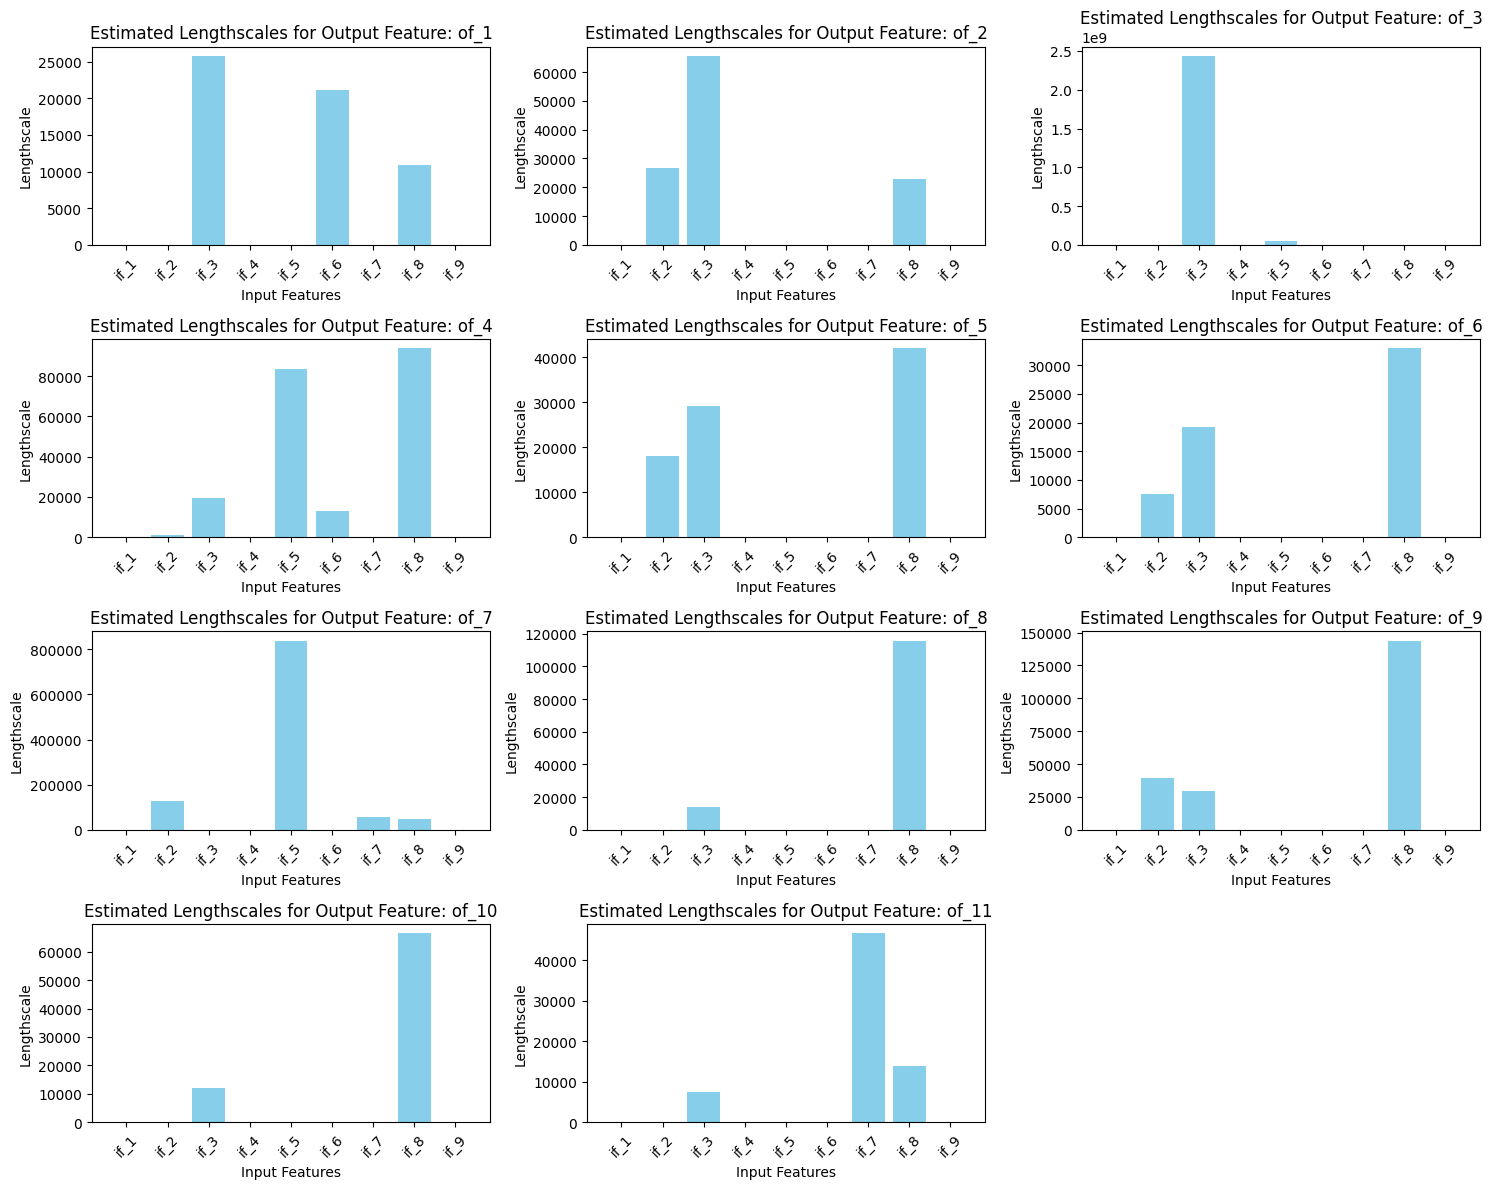

In [204]:
# visualize lengthscales per output feature

plt.figure(figsize=(15, 12))

for i, of in enumerate(of_names):
    plt.subplot(4, 3, i+1)
    plt.bar(if_names, lengthscales[of], color='skyblue')
    plt.title(f"Estimated Lengthscales for Output Feature: {of}")
    plt.xlabel("Input Features")
    plt.ylabel("Lengthscale")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [199]:
# list most significant input features for each output feature based on lengthscales
# smaller lengthscale means more significant feature, so we sort in ascending order
for of in of_names:
    sorted_indices = np.argsort(lengthscales[of])
    sorted_if_names = [if_names[idx] for idx in sorted_indices]
    sorted_lengthscales = lengthscales[of][sorted_indices]
    print(f"Most significant input features for output feature '{of}':")
    for if_name, ls in zip(sorted_if_names, sorted_lengthscales):
        print(f"  {if_name}: lengthscale={ls:.4f}")

Most significant input features for output feature 'of_1':
  if_4: lengthscale=1.0000
  if_1: lengthscale=4.3503
  if_7: lengthscale=5.8876
  if_2: lengthscale=6.2254
  if_9: lengthscale=8.6370
  if_5: lengthscale=18.9144
  if_8: lengthscale=10900.4648
  if_6: lengthscale=21090.6970
  if_3: lengthscale=25788.4059
Most significant input features for output feature 'of_2':
  if_4: lengthscale=1.0000
  if_1: lengthscale=4.2534
  if_7: lengthscale=4.5707
  if_9: lengthscale=6.3968
  if_6: lengthscale=16.7402
  if_5: lengthscale=17.9192
  if_8: lengthscale=22914.2492
  if_2: lengthscale=26738.5031
  if_3: lengthscale=65604.7872
Most significant input features for output feature 'of_3':
  if_7: lengthscale=2.5297
  if_6: lengthscale=5.1761
  if_9: lengthscale=5.9464
  if_1: lengthscale=8.5270
  if_4: lengthscale=673.2249
  if_2: lengthscale=2164.5683
  if_8: lengthscale=1624786.6846
  if_5: lengthscale=50207451.4977
  if_3: lengthscale=2435714867.4539
Most significant input features for outp

In [182]:
# pick top 4 out of all most significant input features from all the output features
top_features = set()
for of in of_names:
    sorted_indices = np.argsort(lengthscales[of])
    top_if_names = [if_names[idx] for idx in sorted_indices[:4]]
    top_features.update(top_if_names)
print("Top input features across all output features:", top_features)

Top input features across all output features: {'if_3', 'if_4', 'if_7', 'if_9', 'if_2', 'if_1', 'if_6'}


In [200]:
print(feature_renamer.get_raw_column_name('if_4'))

SOI1


In [ ]:
learned_hyperparameters = data_analyzer.construct_learned_hyperparameters(
    lengthscales, noises=output_noise_variances_array, output_columns=of_names)
learned_hyperparameters

{'of_1': {'lengthscales': array([4.35032029e+00, 6.22540764e+00, 2.57884059e+04, 1.00000000e+00,
         1.89144003e+01, 2.10906970e+04, 5.88758695e+00, 1.09004648e+04,
         8.63696070e+00]),
  'noise': np.float64(1.0217391304347827),
  'signal_variance': 1.0},
 'of_2': {'lengthscales': array([4.25344128e+00, 2.67385031e+04, 6.56047872e+04, 1.00000000e+00,
         1.79191816e+01, 1.67401755e+01, 4.57068739e+00, 2.29142492e+04,
         6.39682807e+00]),
  'noise': np.float64(1.0217391304347827),
  'signal_variance': 1.0},
 'of_3': {'lengthscales': array([8.52700076e+00, 2.16456830e+03, 2.43571487e+09, 6.73224892e+02,
         5.02074515e+07, 5.17608045e+00, 2.52967185e+00, 1.62478668e+06,
         5.94641598e+00]),
  'noise': np.float64(1.0217391304347827),
  'signal_variance': 1.0},
 'of_4': {'lengthscales': array([5.26575481e+00, 9.47567623e+02, 1.95157943e+04, 1.00000000e+00,
         8.33985545e+04, 1.32503086e+04, 3.03816184e+00, 9.36890684e+04,
         8.98275333e+00]),
  

In [211]:
# split data into train and test sets
from sklearn.model_selection import train_test_split

training_data, testing_data = train_test_split(scaled_df, test_size=0.1, random_state=42)

print("Training data shape:", training_data.shape)
print("Testing data shape:", testing_data.shape)

Training data shape: (42, 29)
Testing data shape: (5, 29)


In [212]:
# Just checking output 1 to see if everything is working fine
print("Training data output feature 1 stats:")
print(training_data['of_1'].describe())

Training data output feature 1 stats:
count    42.000000
mean     -0.034130
std       1.056673
min      -3.687789
25%      -0.388045
50%       0.222013
75%       0.718135
max       1.179741
Name: of_1, dtype: float64


In [230]:
fitted_gps = data_analyzer.fit_training_data(
    lengthscales=lengthscales, 
    noises = output_noise_variances_array,
    output_features=[of_names[0]], 
    X=training_data[if_names].values, 
    y=training_data[of_names].values
)

print(f"Fitted GPS: {fitted_gps}")

Fitted GPS: {'of_1': GaussianProcessRegressor(alpha=np.float64(1.0217391304347827),
                         kernel=1**2 * RBF(length_scale=[4.35, 6.23, 2.58e+04, 1, 18.9, 2.11e+04, 5.89, 1.09e+04, 8.64]),
                         optimizer=None, random_state=42)}


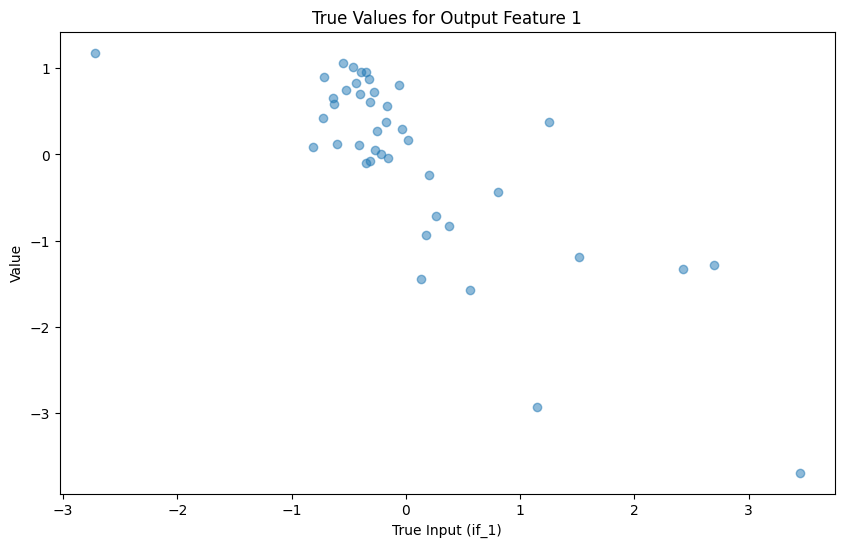

In [231]:
# visualize true for output feature 1
plt.figure(figsize=(10, 6))
plt.scatter(training_data[if_names[0]], training_data[of_names[0]], alpha=0.5)
plt.xlabel("True Input (if_1)")
plt.ylabel("Value")
plt.title("True Values for Output Feature 1")
plt.show()

In [232]:
# predict on test set using the fitted GP for output feature 1
X_test = testing_data[if_names].values
fitted_response = data_analyzer.predict(X_test, fitted_gps)
fitted_response

{'of_1': {'mean': array([-0.31233982,  0.16691423, -0.08451714,  0.68781629,  0.17659493]),
  'std': array([0.18375505, 0.17904572, 0.17551694, 0.28214379, 0.18132276])}}

In [233]:
print(testing_data[of_names[0]].values)
print(fitted_response[of_names[0]]['mean'])

[-0.18431042  0.65061341 -0.03983566  0.82472282  0.18224932]
[-0.31233982  0.16691423 -0.08451714  0.68781629  0.17659493]


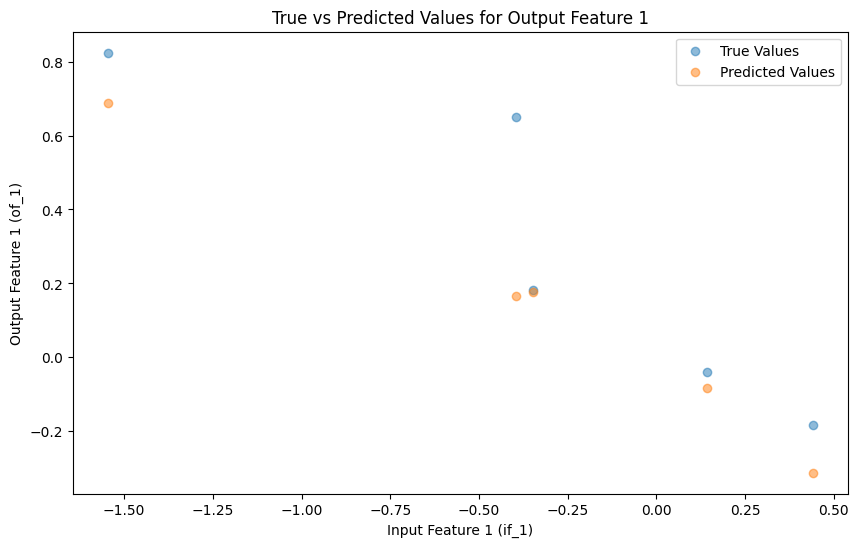

In [234]:
# plot X_test output feature 1 predictions vs true values
plt.figure(figsize=(10, 6))
plt.scatter(testing_data[if_names[0]], testing_data[of_names[0]], alpha=0.5, label='True Values')
plt.scatter(testing_data[if_names[0]], fitted_response[of_names[0]]['mean'], alpha=0.5, label='Predicted Values')
plt.xlabel("Input Feature 1 (if_1)")
plt.ylabel("Output Feature 1 (of_1)")
plt.title("True vs Predicted Values for Output Feature 1")
plt.legend()
plt.show()

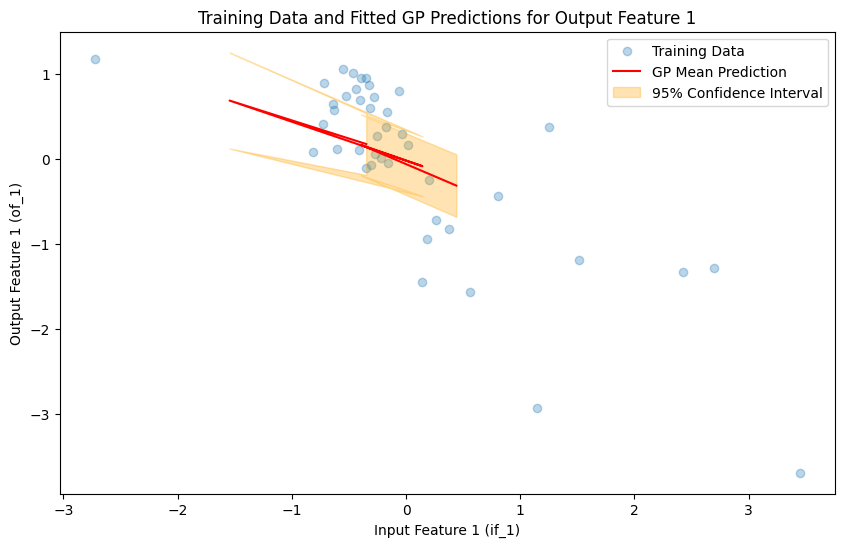

In [236]:
# plot all training data and draw confidence intervals on fitted GP predictions for output feature 1
plt.figure(figsize=(10, 6))
plt.scatter(training_data[if_names[0]], training_data[of_names[0]], alpha=0.3, label='Training Data')
plt.xlabel("Input Feature 1 (if_1)")
plt.ylabel("Output Feature 1 (of_1)")
plt.title("Training Data and Fitted GP Predictions for Output Feature 1")
# --- IGNORE ---
mean_predictions = fitted_response[of_names[0]]['mean']
stddev_predictions = fitted_response[of_names[0]]['std']
# --- IGNORE ---
plt.plot(testing_data[if_names[0]], mean_predictions, color='red', label='GP Mean Prediction')
plt.fill_between(
    testing_data[if_names[0]],
    mean_predictions - 2 * stddev_predictions,
    mean_predictions + 2 * stddev_predictions,
    color='orange',
    alpha=0.3,
    label='95% Confidence Interval'
)
plt.legend()
plt.show()